# Описание датасета

📝 У нас есть таблица excel с металлургического завода Русал за сентябрь 2022 года. В ней по дням расписаны показатели основных примесей в ваннах, в которых варят алюминий. Нашей задачей является построить модель, которая будет по замерам, сделанными до варки, прогнозировать итоговую марку продукта. Колонка Марка Расч. - это марка, которую рассчитал лаборант на предприятии, нужно как минимум перебить точность его прогнозирования.

В столбцах P-S приведены результаты контрольных замеров составов в ваннах через некоторое время. Но важно понимать, что эти замеры не являются итоговыми, даже после них марка алюминия в сплаве может изменится (см. ст. Марка Факт.). Такие несовпадения помечены желтым маркером.

# Код

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Импорт таблицы

ℹ️ Так как медь очень незначительно влияет на марку, основная проблема для аллюминия в железе. Марки высокой чистоты (от А95 и выше) встречаются редко, а для самых "ходовых" марок технической чистоты (от А6 до А85) медь не меняется, поэтому и замеры по ней можем не учитывать в данной работе.

In [ ]:
import pandas as pd

file_path = 'сентябрь 2022 (портал) (2).xlsx'

all_sheets = pd.ExcelFile(file_path).sheet_names

df_list = []
for sheet in all_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, header=4)
    df = df.dropna(how='all', axis=1)
    df = df.dropna(how='all', axis=0)
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)

df_final = df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 13, 14, 15, 16, 17, 18]].copy()

df_final.columns = [
    'Номер_ванны', 
    'Вес_металла', 
    'Дата_анализа',
    'Si_эл-р',
    'Si_среднее', 
    'Si_ковш',
    'Fe_эл-р',
    'Fe_среднее',
    'Fe_ковш',
    'Марка_рас.', 
    'Марка_факт.',
    'Контрольная_дата',
    'Si_контр.', 
    'Fe_контр.', 
    'Марка_контр.'
]

print(f"✅ Импортировано {len(df_final)} строк из {len(all_sheets)} листов")
print(f"📊 Колонки: {list(df_final.columns)}")

✅ Импортировано 15807 строк из 30 листов
📊 Колонки: ['Номер_ванны', 'Вес_металла', 'Дата_анализа', 'Si_эл-р', 'Si_среднее', 'Si_ковш', 'Fe_эл-р', 'Fe_среднее', 'Fe_ковш', 'Марка_рас.', 'Марка_факт.', 'Контрольная_дата', 'Si_контр.', 'Fe_контр.', 'Марка_контр.']


In [4]:
df_final

,Номер_ванны,Вес_металла,Дата_анализа,Si_эл-р,Si_среднее,Si_ковш,Fe_эл-р,Fe_среднее,Fe_ковш,Марка_рас.,Марка_факт.,Контрольная_дата,Si_контр.,Fe_контр.,Марка_контр.
0,735,2040.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
1,735,5078.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
2,735,2293.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
3,735,5052.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
4,732,NaN,31.08.22,0.055,NaN,0.086,0.193,NaN,0.601,NaN,A0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15802,1256,1281.0,30.09.22,0.323,0.325,0.276,1.193,2.388,2.161,AB97,AB97,01.10.22,0.325,1.153,AB97
15803,1246,1291.0,30.09.22,0.479,NaN,NaN,4.172,NaN,NaN,NaN,NaN,01.10.22,0.452,3.825,AB91
15804,1238,1291.0,30.09.22,0.172,NaN,NaN,1.789,NaN,NaN,NaN,NaN,01.10.22,0.168,1.721,AB97
15805,1236,1281.0,30.09.22,0.588,0.640,0.631,3.169,2.774,2.771,AB91,AB91,01.10.22,0.575,3.187,AB91


## Обработка данных

📄 Для прогнозирования марки итогового сплава алюминия нам необходимо иметь все признаки, связанные с процентами примеси железа и кремния. После проанализируем какие вносят больший вклад в результат прогнозирования.

 Проведя анализ записей, можно сделать вывод, что пропуск в этих ячейках имеется только в тех строках, где не указан вес металла партии, поэтому удалим все такие записи. Также обработаем "пропуски", которые получаются в ходе объединения ячеек в excel - сделаем это с помощью forward fill.

In [ ]:
df_final = df_final.dropna(subset=['Вес_металла'])

df_final['Si_среднее'] = df_final['Si_среднее'].ffill()
df_final['Si_ковш'] = df_final['Si_ковш'].ffill()
df_final['Fe_среднее'] = df_final['Fe_среднее'].ffill()
df_final['Fe_ковш'] = df_final['Fe_ковш'].ffill()
df_final['Марка_рас.'] = df_final['Марка_рас.'].ffill()
df_final['Марка_факт.'] = df_final['Марка_факт.'].ffill()

In [6]:
df_final

,Номер_ванны,Вес_металла,Дата_анализа,Si_эл-р,Si_среднее,Si_ковш,Fe_эл-р,Fe_среднее,Fe_ковш,Марка_рас.,Марка_факт.,Контрольная_дата,Si_контр.,Fe_контр.,Марка_контр.
0,735,2040.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
1,735,5078.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
2,735,2293.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
3,735,5052.0,31.08.22,0.341,0.341,NaN,1.147,1.147,NaN,AB97,NaN,NaN,NaN,NaN,NaN
6,731,1042.0,30.08.22,0.050,0.053,0.059,0.180,0.186,0.197,A7Э,A7Э,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15802,1256,1281.0,30.09.22,0.323,0.325,0.276,1.193,2.388,2.161,AB97,AB97,01.10.22,0.325,1.153,AB97
15803,1246,1291.0,30.09.22,0.479,0.325,0.276,4.172,2.388,2.161,AB97,AB97,01.10.22,0.452,3.825,AB91
15804,1238,1291.0,30.09.22,0.172,0.325,0.276,1.789,2.388,2.161,AB97,AB97,01.10.22,0.168,1.721,AB97
15805,1236,1281.0,30.09.22,0.588,0.640,0.631,3.169,2.774,2.771,AB91,AB91,01.10.22,0.575,3.187,AB91


Удаляем первые четыре строки, так как это единственные записи, где нет Марки фактической - целевой признак.

In [ ]:
df_final = df_final.iloc[4:].reset_index(drop=True) 

Проверим напоследок пропуски во всех ключевых колонках.

In [ ]:
print(f"Si_эл-р: {df_final['Si_эл-р'].isna().sum()}")
print(f"Si_среднее: {df_final['Si_среднее'].isna().sum()}")
print(f"Si_ковш: {df_final['Si_ковш'].isna().sum()}")
print(f"Fe_эл-р: {df_final['Fe_эл-р'].isna().sum()}")
print(f"Fe_среднее: {df_final['Fe_среднее'].isna().sum()}")
print(f"Fe_ковш: {df_final['Fe_ковш'].isna().sum()}")
print(f"Марка_расчетная: {df_final['Марка_рас.'].isna().sum()}")
print(f"Марка_фактическая: {df_final['Марка_факт.'].isna().sum()}")

Si_эл-р: 0
Si_среднее: 0
Si_ковш: 0
Fe_эл-р: 0
Fe_среднее: 0
Fe_ковш: 0
Марка_расчетная: 0
Марка_фактическая: 0


In [9]:
df_final

,Номер_ванны,Вес_металла,Дата_анализа,Si_эл-р,Si_среднее,Si_ковш,Fe_эл-р,Fe_среднее,Fe_ковш,Марка_рас.,Марка_факт.,Контрольная_дата,Si_контр.,Fe_контр.,Марка_контр.
0,731,1042.0,30.08.22,0.050,0.053,0.059,0.180,0.186,0.197,A7Э,A7Э,NaN,NaN,NaN,NaN
1,758,1042.0,27.08.22,0.053,0.053,0.059,0.203,0.186,0.197,A7Э,A7Э,NaN,NaN,NaN,NaN
2,730,521.0,30.08.22,0.062,0.053,0.059,0.184,0.186,0.197,A7Э,A7Э,NaN,NaN,NaN,NaN
3,756,1042.0,29.08.22,0.053,0.053,0.059,0.195,0.186,0.197,A7Э,A7Э,NaN,NaN,NaN,NaN
4,738,1040.0,30.08.22,0.050,0.053,0.059,0.166,0.186,0.197,A7Э,A7Э,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15541,1256,1281.0,30.09.22,0.323,0.325,0.276,1.193,2.388,2.161,AB97,AB97,01.10.22,0.325,1.153,AB97
15542,1246,1291.0,30.09.22,0.479,0.325,0.276,4.172,2.388,2.161,AB97,AB97,01.10.22,0.452,3.825,AB91
15543,1238,1291.0,30.09.22,0.172,0.325,0.276,1.789,2.388,2.161,AB97,AB97,01.10.22,0.168,1.721,AB97
15544,1236,1281.0,30.09.22,0.588,0.640,0.631,3.169,2.774,2.771,AB91,AB91,01.10.22,0.575,3.187,AB91


## Отбор признаков и подготовка датасета

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df_ml = df_final.copy()

feature_cols = [
    'Номер_ванны', 
    'Вес_металла', 
    'Si_эл-р', 
    'Si_среднее', 
    'Si_ковш',
    'Fe_эл-р', 
    'Fe_среднее', 
    'Fe_ковш']


# номер ванны - str в таблице
le_van = LabelEncoder()
df_ml['Номер_ванны_enc'] = le_van.fit_transform(df_ml['Номер_ванны'].astype(str))


le_target = LabelEncoder()
df_ml['target'] = le_target.fit_transform(df_ml['Марка_факт.'])

print(f"\nЦелевая переменная: {len(le_target.classes_)} классов")
print(f"Примеры марок: {le_target.classes_[:10]}")


Целевая переменная: 10 классов
Примеры марок: ['A0' 'A35' 'A5' 'A6' 'A7' 'A7Э' 'A8' 'A85' 'AB91' 'AB97']


🔢 Формируем матрицу признаков, а также проведем нормализацию числовых признаков.

In [ ]:
feature_matrix_cols = ['Номер_ванны_enc', 'Вес_металла', 'Si_эл-р', 'Si_среднее', 
                       'Si_ковш', 'Fe_эл-р', 'Fe_среднее', 'Fe_ковш']

X = df_ml[feature_matrix_cols]
y = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nРазмер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

scaler = StandardScaler()
numeric_features = ['Вес_металла', 'Si_эл-р', 'Si_среднее', 'Si_ковш', 
                    'Fe_эл-р', 'Fe_среднее', 'Fe_ковш']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])


Размер обучающей выборки: 12436
Размер тестовой выборки: 3110


## Обучение моделей

Для данной задачи лучшим методом решения будет градиентный бустинг. Возьмем три популярные библиотеки, обучим их модели и сравним результаты - выберем лучшую.

In [13]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

In [ ]:
models = {}
results = {}


print("\n🚀 Обучение LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
models['LightGBM'] = lgb_model
results['LightGBM'] = accuracy_lgb
print(f"LightGBM Accuracy: {accuracy_lgb:.4f}")


print("\n🚀 Обучение XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
models['XGBoost'] = xgb_model
results['XGBoost'] = accuracy_xgb
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")




print("\n🚀 Обучение CatBoost...")
cat_model = CatBoostClassifier(
    iterations=200,
    depth=10,
    learning_rate=0.1,
    random_seed=42,
    verbose=False
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
accuracy_cat = accuracy_score(y_test, y_pred_cat)
models['CatBoost'] = cat_model
results['CatBoost'] = accuracy_cat
print(f"CatBoost Accuracy: {accuracy_cat:.4f}")


🚀 Обучение LightGBM...
LightGBM Accuracy: 0.8695

🚀 Обучение XGBoost...
XGBoost Accuracy: 0.9981

🚀 Обучение CatBoost...
CatBoost Accuracy: 0.9984


🔧 Так как лучшая модель показала точность очень близкую к 100%, то нет смысла у них проводить подбор гиперпараметров.

## Результаты обучения

In [15]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
})
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))



   Model  Accuracy
CatBoost  0.998392
 XGBoost  0.998071
LightGBM  0.869453


🔍 Определим теперь важность признаков, которые мы выбрали.

Лучшая модель: CatBoost
        feature  importance
        Fe_ковш   84.175218
        Si_ковш    7.324026
     Fe_среднее    2.627985
     Si_среднее    1.535967
Номер_ванны_enc    1.517727
    Вес_металла    1.483328
        Si_эл-р    0.752176
        Fe_эл-р    0.583573


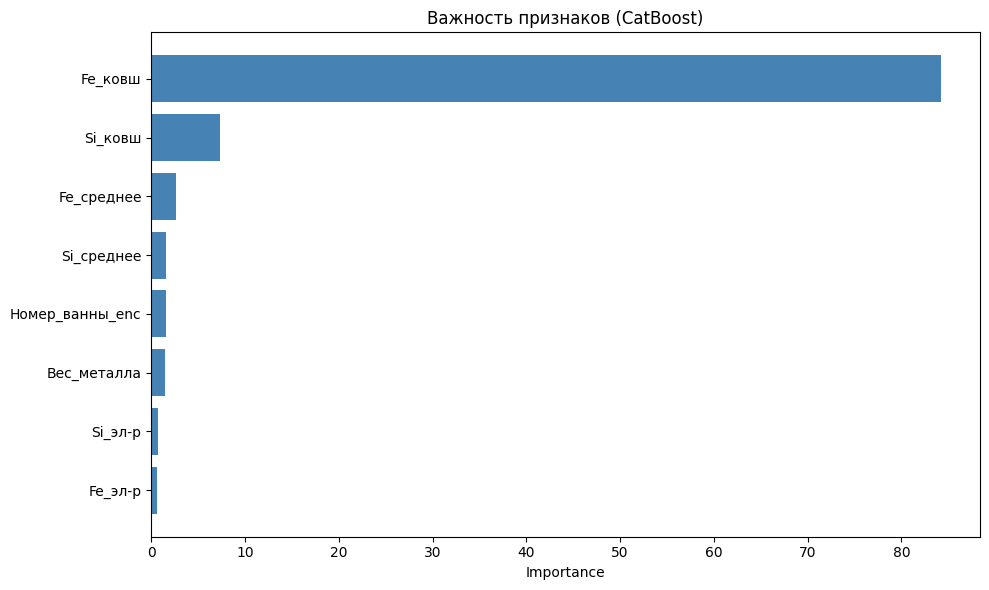

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
importance = best_model.feature_importances_
print(f"Лучшая модель: {best_model_name}")


feature_importance = pd.DataFrame({
    'feature': feature_matrix_cols,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feature_importance.to_string(index=False))


plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title(f'Важность признаков ({best_model_name})')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

📊 Построим для анализа матрицу ошибок лучшей модели.

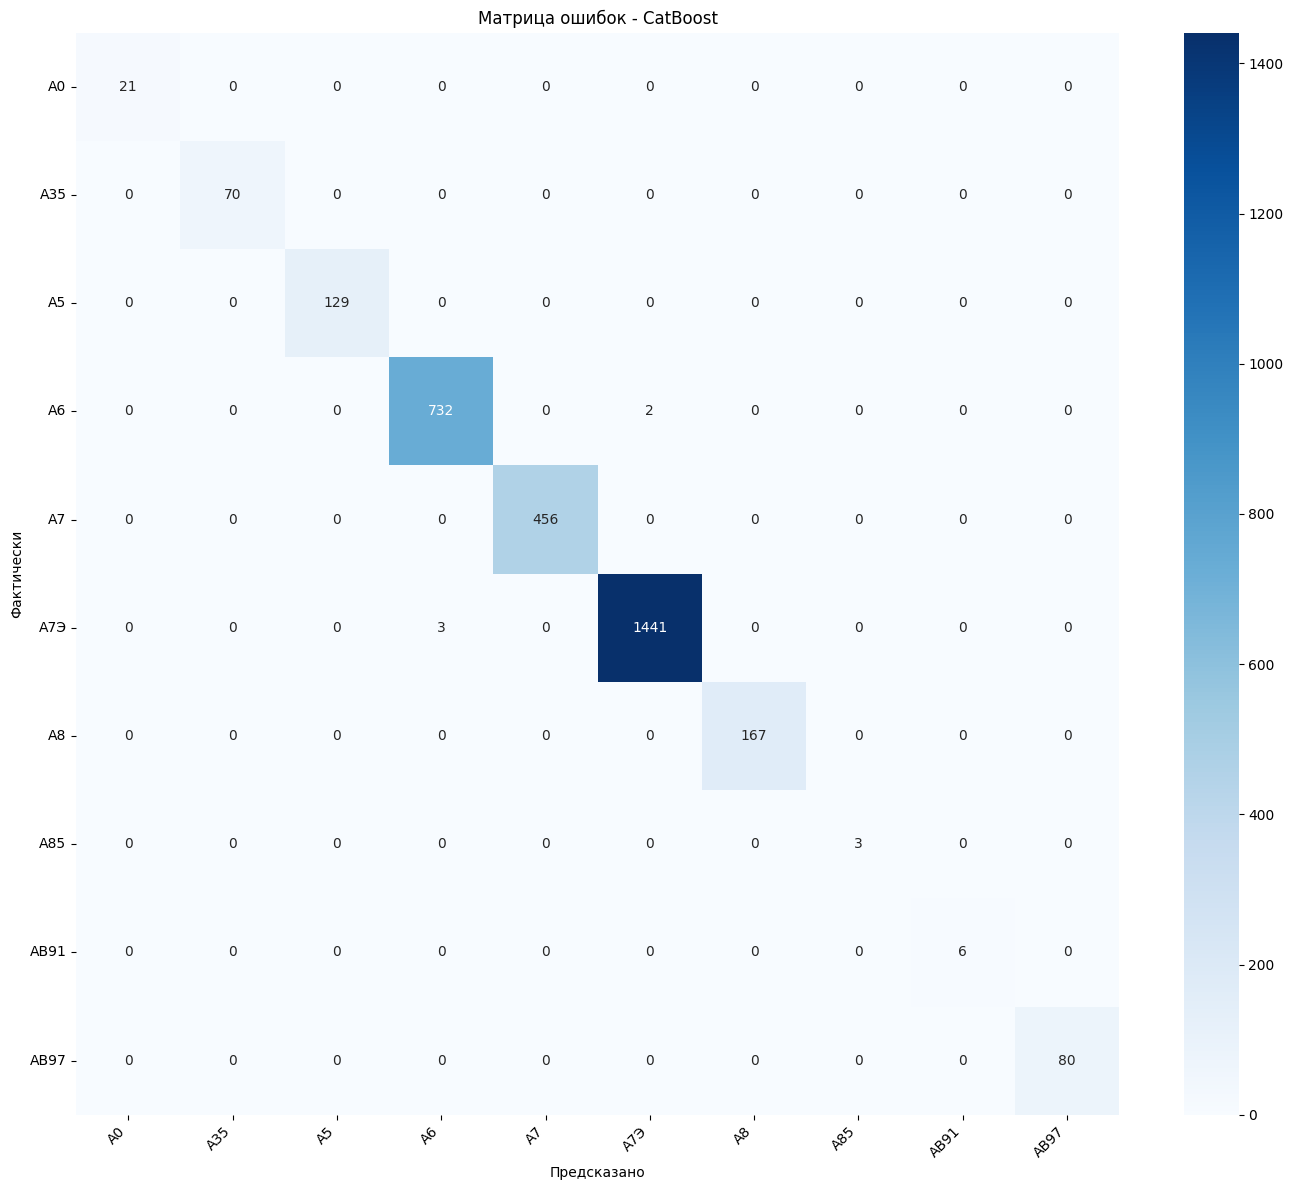

In [ ]:
y_pred_best = best_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred_best)

mark_names = le_target.classes_ 

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=mark_names, 
            yticklabels=mark_names)
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title(f'Матрица ошибок - {best_model_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Итоги. Сравнение точностей пронозирования и расчета марки алюминия

In [ ]:
y_pred_marks_test = le_target.inverse_transform(y_pred_best)
y_true_marks_test = le_target.inverse_transform(y_test)
y_manual_marks_test = df_ml.loc[y_test.index, 'Марка_рас.'].values

# датафрейм с результатами для анализа
results_df = pd.DataFrame({
    'индекс_ml': y_test.index,  # индексы надо из df_ml, а не df_final
    'факт': y_true_marks_test,
    'Модель': y_pred_marks_test,
    'лаборант': y_manual_marks_test
})


model_accuracy = accuracy_score(y_true_marks_test, y_pred_marks_test)
manual_accuracy = accuracy_score(y_true_marks_test, y_manual_marks_test)

print("="*60)
print("📊 СРАВНЕНИЕ ТОЧНОСТИ НА ТЕСТОВЫХ ДАННЫХ")
print("="*60)
print(f"Тестовая выборка: {len(y_test)} образцов")
print(f"\n🤖 Точность модели ({best_model_name}): {model_accuracy:.4f} ({model_accuracy:.2%})")
print(f"👨‍🔬 Точность лаборанта (расчетная марка): {manual_accuracy:.4f} ({manual_accuracy:.2%})")


print("\n" + "="*60)
print("📈 РАСПРЕДЕЛЕНИЕ ОШИБОК:\n")

def show_samples(ml_indices, description):
    print(f"\n{description}")
    sample_data = df_final.loc[ml_indices].copy()
    sample_data['факт'] = results_df.set_index('индекс_ml').loc[ml_indices, 'факт'].values
    sample_data['Модель'] = results_df.set_index('индекс_ml').loc[ml_indices, 'Модель'].values
    display(sample_data[['Номер_ванны', 'Дата_анализа', 'Si_среднее', 'Si_ковш', 'Fe_среднее', 'Fe_ковш',
                         'Марка_рас.', 'Модель', 'Марка_факт.']].head(2))




both_right_idx = results_df[(results_df['Модель'] == results_df['факт']) & 
                            (results_df['лаборант'] == results_df['факт'])]['индекс_ml'].values[:2]
if len(both_right_idx) > 0:
    show_samples(both_right_idx, "✅ Оба правы ✅:")
else:
    print("\n✅ Нет примеров, где оба правы")

model_right_idx = results_df[(results_df['Модель'] == results_df['факт']) & 
                             (results_df['лаборант'] != results_df['факт'])]['индекс_ml'].values[:2]
if len(model_right_idx) > 0:
    show_samples(model_right_idx, " ✅ Модель права, Лаборант ошибся ❌:")
else:
    print("\nНет примеров, где только модель права")

manual_right_idx = results_df[(results_df['лаборант'] == results_df['факт']) & 
                              (results_df['Модель'] != results_df['факт'])]['индекс_ml'].values[:2]
if len(manual_right_idx) > 0:
    show_samples(manual_right_idx, "❌ Модель ошиблась, Лаборант прав ✅:")
else:
    print("\nНет примеров, где только лаборант прав")

both_wrong_idx = results_df[(results_df['Модель'] != results_df['факт']) & 
                            (results_df['лаборант'] != results_df['факт'])]['индекс_ml'].values[:2]
if len(both_wrong_idx) > 0:
    show_samples(both_wrong_idx, "❌ Оба ошиблись ❌:")
else:
    print("\n❌ Нет примеров, где оба ошиблись")

📊 СРАВНЕНИЕ ТОЧНОСТИ НА ТЕСТОВЫХ ДАННЫХ
Тестовая выборка: 3110 образцов

🤖 Точность модели (CatBoost): 0.9984 (99.84%)
👨‍🔬 Точность лаборанта (расчетная марка): 0.5479 (54.79%)

📈 РАСПРЕДЕЛЕНИЕ ОШИБОК:


✅ Оба правы ✅:


,Номер_ванны,Дата_анализа,Si_среднее,Si_ковш,Fe_среднее,Fe_ковш,Марка_рас.,Модель,Марка_факт.
6870,814,13.09.22,0.086,0.091,0.188,0.206,A6,A6,A6
11011,882,19.09.22,0.061,0.069,0.179,0.186,A7Э,A7Э,A7Э



 ✅ Модель права, Лаборант ошибся ❌:


,Номер_ванны,Дата_анализа,Si_среднее,Si_ковш,Fe_среднее,Fe_ковш,Марка_рас.,Модель,Марка_факт.
10383,712,20.09.22,0.050,0.064,0.177,0.356,A7Э,A35,A35
9223,1221,09.09.22,0.054,0.069,0.186,0.239,A7Э,A6,A6



❌ Модель ошиблась, Лаборант прав ✅:


,Номер_ванны,Дата_анализа,Si_среднее,Si_ковш,Fe_среднее,Fe_ковш,Марка_рас.,Модель,Марка_факт.
10847,1201,13.09.22,0.075,0.103,0.178,0.169,A7Э,A6,A7Э
10848,1290,21.09.22,0.075,0.103,0.178,0.169,A7Э,A6,A7Э



❌ Оба ошиблись ❌:


,Номер_ванны,Дата_анализа,Si_среднее,Si_ковш,Fe_среднее,Fe_ковш,Марка_рас.,Модель,Марка_факт.
9666,1112,15.09.22,0.05,0.072,0.187,0.2,A7Э,A7Э,A6
9667,1113,13.09.22,0.05,0.072,0.187,0.2,A7Э,A7Э,A6


👀 Наглядное сравнение двух прогнозов по 10 случайным строкам из основного датафрейма.

In [ ]:
import random
from sklearn.metrics import accuracy_score

random_indices = random.sample(range(len(df_final)), 10)
sample_df = df_final.iloc[random_indices].copy()

sample_df['Номер_ванны_enc'] = le_van.transform(sample_df['Номер_ванны'].astype(str))


numeric_cols = ['Вес_металла', 'Si_эл-р', 'Si_среднее', 'Si_ковш', 
                'Fe_эл-р', 'Fe_среднее', 'Fe_ковш']
for col in numeric_cols:
    if col in sample_df.columns:
        sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')
        sample_df[col].fillna(df_final[col].median(), inplace=True)

feature_cols = ['Номер_ванны_enc', 'Вес_металла', 'Si_эл-р', 'Si_среднее', 
                'Si_ковш', 'Fe_эл-р', 'Fe_среднее', 'Fe_ковш']
X_sample = sample_df[feature_cols]

y_pred_sample = best_model.predict(X_sample)
y_pred_marks = le_target.inverse_transform(y_pred_sample)

sample_df['Марка_предсказанная'] = y_pred_marks
sample_df['Марка_фактическая'] = sample_df['Марка_факт.']


accuracy_model = accuracy_score(sample_df['Марка_факт.'], sample_df['Марка_предсказанная'])


accuracy_manual = accuracy_score(sample_df['Марка_факт.'], sample_df['Марка_рас.'])


result_table = sample_df[['Номер_ванны', 'Вес_металла', 'Si_эл-р', 'Si_среднее', 'Si_ковш',
                          'Fe_эл-р', 'Fe_среднее', 'Fe_ковш', 'Марка_рас.', 
                          'Марка_предсказанная', 'Марка_фактическая']]

display(result_table)

print(f"Точность модели на 10 случайных строках: {accuracy_model:.2%} ({int(accuracy_model*10)} из 10)")
print(f"Точность ручного расчёта (лаборантом): {accuracy_manual:.2%} ({int(accuracy_manual*10)} из 10)")

,Номер_ванны,Вес_металла,Si_эл-р,Si_среднее,Si_ковш,Fe_эл-р,Fe_среднее,Fe_ковш,Марка_рас.,Марка_предсказанная,Марка_фактическая
14363,1118,1237.0,0.056,0.052,0.059,0.174,0.174,0.187,A7Э,A7Э,A7Э
1047,769,1044.0,0.061,0.059,0.058,0.160,0.168,0.158,A7Э,A7,A7
15030,1216,1128.0,0.061,0.060,0.072,0.187,0.184,0.234,A7Э,A6,A6
13469,740,938.0,0.042,0.052,0.066,0.128,0.152,0.162,A7,A7,A7
10851,1204,1287.0,0.045,0.046,0.080,0.191,0.192,0.233,A7Э,A6,A6
13460,1282,1276.0,0.062,0.054,0.070,0.195,0.191,0.200,A7Э,A7Э,A7Э
1614,775,1057.0,0.053,0.053,0.058,0.181,0.186,0.217,A7Э,A6,A6
11697,1093,1057.0,0.039,0.043,0.048,0.128,0.130,0.138,A7,A7,A7
7,752,993.0,0.048,0.045,0.048,0.159,0.158,0.159,A7,A7,A7
576,716,992.0,0.054,0.051,0.053,0.203,0.188,0.192,A7Э,A7Э,A7Э


Точность модели на 10 случайных строках: 100.00% (10 из 10)
Точность ручного расчёта (лаборантом): 60.00% (6 из 10)
